In [60]:
import boto3
import glob
import os, ssl, certifi, requests, json
from langgraph.graph import StateGraph, START, END
from IPython.display import Image, display
from langchain_core.documents import Document
from langchain_text_splitters import RecursiveCharacterTextSplitter
from typing import List, Dict, TypedDict
from langchain_aws import  ChatBedrock
from langchain_classic.retrievers.ensemble import EnsembleRetriever
from langchain_community.retrievers.bm25 import BM25Retriever
from pydantic import BaseModel, Field
from langchain_core.globals import set_llm_cache
from langchain_community.cache import SQLiteCache
from langchain_community.document_loaders import PyPDFLoader
from langchain_core.prompts import PromptTemplate
from langsmith import traceable, Client
from botocore.config import Config
import pickle
import re
from pathlib import Path
from rank_bm25 import BM25Okapi


In [61]:
# CONSTANTS
os.environ["LANGCHAIN_TRACING_V2"] = "false"
os.environ["LANGCHAIN_TRACING"] = "false"
os.environ["LANGCHAIN_API_KEY"] = "none"
# Your vectorstore defined path
LOCAL_VECTORSTORE_PATH = '/Users/sridhartondapi/Documents/python_self_corr_rag_prj_v1/data/chroma_db'

# Your inference model id
MODEL_ID = "us.anthropic.claude-sonnet-4-20250514-v1:0" 

# Your embedding model id
EMBEDDING_MODEL_ID = "amazon.titan-embed-text-v2:0"

# Chroma Collection name 

collection_name = "pdf_knowledge_base"

# Model params

CONFIDENCE_THRESHOLD = 0.80

bedrock_config = Config(
    connect_timeout=60,          # seconds to establish connection
    read_timeout=300,            # ← most important: 5 minutes — start here
    retries={'max_attempts': 3}
)

# CONSTANTS & PATHS
CACHE_DIR = Path('/Users/sridhartondapi/Documents/python_self_corr_rag_prj_v1/retrieval/agents/memory')
CACHE_DIR.mkdir(parents=True, exist_ok=True)

DOCS_CACHE_PATH = CACHE_DIR / "documents_cache.pkl"
BM25_CACHE_PATH = CACHE_DIR / "bm25_index.pkl"
PDF_SOURCE_PATH = "/Users/sridhartondapi/Documents/python_self_corr_rag_prj_v1/ingestion/source/reports/*.pdf"

# Your AWS Boto3 connection details
bedrock = boto3.client(service_name="bedrock-runtime", 
                        region_name='us-east-1',
                        config = bedrock_config)

In [62]:
class NavigationResponse(BaseModel):
    question: str = Field()
    answer: str = Field()

In [63]:
PROMPT_TEMPLATE = """
=== RELEVANT DOCUMENTS — READ THESE FIRST (THIS IS THE ONLY EVIDENCE) ===
{context}

=== INSTRUCTIONS (follow strictly) ===
**Identify the document and filters to use based strictly on the provided context chunks above.**

**1. STRICT FILTER VALIDATION RULE (CRITICAL):**
- You must verify that EVERY filter requested in the question (e.g., "Status", "Risk", "Date") is explicitly mentioned as a column or attribute within the context chunk for a document.
- If a document is relevant to the "State" and "Event" but DOES NOT mention the "Status" column in its context, you MUST EXCLUDE that document from the answer for that specific query.
- Providing a navigation instruction for a document that lacks a required filter is a failure.

**Instructions**
- For questions like "How to check [something]?", "How many [something] by [something]?", "How to find [entity_1] by [entity_2] and [entity_3] [value]", or "Show [something]":
- Extract all main entities explicitly mentioned or implied in the question.
- To map entities to document-specific columns: Check the synonym reference document 'Business attribute synonym reference.pdf' first.
- **COMPREHENSIVE MULTI-DOCUMENT SEARCH RULE:** You must examine every single chunk in the context. If the entities or filters are present in multiple documents (e.g., Submission Report, Test Day Report, and TDTK Report), you are STRICTLY REQUIRED to list ALL of them in a numbered list. Do not stop searching after finding the first relevant document.
- For date-based queries (e.g., "test date", "started testing on", "testing on"), you must include all documents with date-related filters: "Test Start Date" in Student Submission Report, and "Actual Start Date" in End to End Dashboard, TDTK Readiness, and Exam schedule Reports.

- **Special case for response formatting:**
- Generalize document names in navigation instructions:
  - "SAT & PSAT Student Submission Report" -> "Student Submission Report of your specific year"
  - "SAT School Day & PSAT Test Day Report" -> "Test Day report of your specific year"
  - "SAT School Day & PSAT End to End Dashboard" -> "End to End Dashboard of your specific year"
  - "PSAT TDTK Readiness" -> "TDTK Readiness report of your specific year"
  - "SAT School Day & PSAT Exam schedule Report" -> "Exam schedule report of your specific year"
- Keep original names in `source()` references (e.g., `source(SAT & PSAT Student Submission Report_final_wo_syn.pdf)`).

- **Response format (Strict Enforcement):**
- Every navigation line MUST start with a capital "**P**" (e.g., "Please navigate to...").
- **If multiple documents contain the entities:** You must use a numbered list.
  1. Please navigate to the [generalized_name_1] and filter [entities] accordingly source([filename_1].pdf)
  2. Please navigate to the [generalized_name_2] and filter [entities] accordingly source([filename_2].pdf)
- **If only one document contains the entities:** "Please navigate to the [generalized_name] and filter [entities] accordingly source([filename].pdf)"
- **If no document contains all entities:** "No relevant document found for [entities]. source(none)"

- Strictly output only the specified response format without any introductory phrases like "Based on the context" or "Here is the answer."

Question: {question}
Answer:
"""

In [64]:
def bedrock_connection():
    return ChatBedrock(
        model_id = MODEL_ID,
        client = bedrock,
        model_kwargs = {
            # PRE-LLM GUARDRAIL #1 
            # "guardrailIdentifier": "rg-your-guardrail-id" # Add this for the guard rail
            "temperature": 0.1,
            "top_p": 0.1,
            "max_tokens": 1024
        }
    )

In [65]:
try:
    llm = bedrock_connection()
except Exception as e:
    print (f"unable to connect to the bedrock: {str(e)}")

In [ ]:

# Data Ingestion and Transformation :: This function is the "plumbing" of your pipeline. It focuses on turning raw, unstructured PDF files into a structured format.
#  It saves the result as a .pkl file so you don't have to re-parse and re-split your PDFs every time you run the script.
def load_and_cache_documents():
    if DOCS_CACHE_PATH.exists():
        print(f"Loading documents from cache: {DOCS_CACHE_PATH}")
        with open(DOCS_CACHE_PATH, "rb") as f:
            return pickle.load(f)
    
    print("No cache found. Loading PDFs from source...")
    pdf_files = glob.glob(PDF_SOURCE_PATH)
    raw_documents = []
    for pdf in pdf_files:
        loader = PyPDFLoader(pdf)
        raw_documents.extend(loader.load())
    
    # Split documents immediately before caching for consistency
    splitter = RecursiveCharacterTextSplitter(chunk_size=200, chunk_overlap=50)
    chunked_docs = splitter.split_documents(raw_documents)
    
    with open(DOCS_CACHE_PATH, "wb") as f:
        pickle.dump(chunked_docs, f)
    
    print(f"Processed and cached {len(chunked_docs)} chunks.")
    return chunked_docs

# Execute loading
chunks = load_and_cache_documents()

Loading documents from cache: /Users/sridhartondapi/Documents/python_self_corr_rag_prj_v1/retrieval/agents/memory/documents_cache.pkl


In [ ]:
# strip punctuation and lowercase everything, turning "The cat sat!" into ['the', 'cat', 'sat'].
def clean_text(text):
    text = text.lower()
    return re.sub(r"\W+", " ", text).split()

# BM25 (Best Matching 25) is a keyword-based ranking algorithm. It calculates how important a word is to a specific document chunk relative to the entire collection.
def get_bm25_index(doc_chunks):
    if BM25_CACHE_PATH.exists():
        print(f"Loading BM25 index from cache: {BM25_CACHE_PATH}")
        with open(BM25_CACHE_PATH, "rb") as f:
            return pickle.load(f)
    
    print("Building BM25 index...")
    tokenized_corpus = [clean_text(doc.page_content) for doc in doc_chunks]
    bm25_obj = BM25Okapi(tokenized_corpus)
    
    with open(BM25_CACHE_PATH, "wb") as f:
        pickle.dump(bm25_obj, f)
    
    print("BM25 index built and cached.")
    return bm25_obj

# Initialize the BM25 index
bm25_index = get_bm25_index(chunks)

Loading BM25 index from cache: /Users/sridhartondapi/Documents/python_self_corr_rag_prj_v1/retrieval/agents/memory/bm25_index.pkl


In [68]:
class AgentState(TypedDict):
    question: str
    answer: str
    sub_queries: List[str]
    retrieved_documents: List[Document]
    retrieved_sources: List[Document]
    iteration: int
    confidence_score: float

In [69]:
custom_prompt = PromptTemplate(
    input_variables = ["context","question"],
    template = PROMPT_TEMPLATE
)

In [70]:
# Create a standard LangChain BM25Retriever using the cached documents
# This ensures compatibility with the rest of your LangGraph nodes
bm25_retriever = BM25Retriever.from_documents(documents=chunks)

class RetrievalContext:
    def __init__(self, retriever):
        self.retriever = retriever
    
    def hybrid_docs(self, query: str, iteration: int):
        # Adaptive k logic as per your original design
        self.retriever.k = 25 + (iteration * 10)
        return self.retriever.invoke(query)

retrieval_ctx = RetrievalContext(bm25_retriever)

In [71]:
def bedrock_cohere_client(question: str, hybrid_docs:List):
    docs_text = [doc.page_content for doc in hybrid_docs]

    payload ={
        "query": question,
        "documents": docs_text,
        "top_n": 20,
        "api_version": 2
    }
    
    response = bedrock.invoke_model(
        modelId = "cohere.rerank-v3-5:0",
        contentType = "application/json",
        accept = "application/json",
        body = json.dumps(payload).encode("utf-8")

    )
    
    results = json.loads(response['body'].read().decode("utf-8"))

    reranked_docs = [hybrid_docs[result['index']] for result in results['results']]

    return reranked_docs      


In [ ]:
def decompose_query(state:AgentState) -> AgentState:
    question = state['question']

    prompt = f"""Break this question into 1-4 sub-queries for a document system.
    Return ONLY a JSON list of strings.
    Question: {question}"""

    response = llm.invoke(prompt).content.strip()
    try:
        sub_queries = json.loads(response)
    except Exception as e:
        sub_queries = [question]
    
    return {**state, "sub_queries": sub_queries}

In [ ]:
from collections import defaultdict

def retrieval_of_the_documents(state: AgentState) -> AgentState:
    question = state["question"]
    sub_queries = state.get("sub_queries", [question])
    current_iter = state.get("iteration", 0)

    all_collected_docs = []

    for query in sub_queries:
        docs = retrieval_ctx.hybrid_docs(query, iteration=current_iter)

        # Increase recall BEFORE reranking
        docs = docs[:50]   # <-- IMPORTANT (was too low effectively)

        reranked = bedrock_cohere_client(question=query, hybrid_docs=docs)

        all_collected_docs.extend(reranked)

    # ✅ STEP 1: Deduplicate  - It combines results from all sub-queries and removes duplicates based on the text content (page_content)
    unique_docs = list({doc.page_content: doc for doc in all_collected_docs}.values())

    # ✅ STEP 2: GROUP BY DOCUMENT (source)
    doc_groups = defaultdict(list)
    for doc in unique_docs:
        source = doc.metadata.get("source", "unknown")
        doc_groups[source].append(doc)


    # ✅ STEP 3: DIVERSIFY (key fix) - forcing the model to look at information from multiple different files.
    MAX_CHUNKS_PER_DOC = 3
    diversified_docs = []

    for source, docs in doc_groups.items():
        diversified_docs.extend(docs[:MAX_CHUNKS_PER_DOC])

    # ✅ STEP 4: OPTIONAL – limit total size
    diversified_docs = diversified_docs[:20]

    return {
        **state,
        "retrieved_documents": diversified_docs,
        "retrieved_sources": list(doc_groups.keys()),
    }

In [74]:
def generate_the_answer(state: AgentState) -> AgentState:
    question = state["question"]
    retrieved_documents = state.get("retrieved_documents", [])

    try:
        context_text = "\n\n".join(
            [f"Source: {doc.metadata.get('source', 'unknown')}\nContent: {doc.page_content}" for doc in retrieved_documents]
        )

        initial_prompt = custom_prompt.format(
            question=question,
            context=context_text
        )

        initial_answer = llm.invoke(initial_prompt).content.strip()

        confidence_prompt = f"""
You are an evaluator. Compare the Answer against the Context for the given Question.
Score the support from 0.0 to 1.0.

Return only a float.

Question: {question}
Answer: {initial_answer}
Context: {context_text}
"""

        raw_score = llm.invoke(confidence_prompt).content.strip()
        clean_score = "".join(c for c in raw_score if c.isdigit() or c == ".")
        confidence_score = float(clean_score) if clean_score else 0.0

        return {
            **state,
            "answer": initial_answer,
            "confidence_score": confidence_score,
        }

    except Exception as e:
        return {
            **state,
            "answer": "unable to get the answer.",
            "confidence_score": 0.0,
        }

In [75]:
def self_correct(state: AgentState) -> AgentState:
    confidence = float(state.get("confidence_score", 0.0))
    curr_iter = state.get("iteration", 0)

    if confidence >= CONFIDENCE_THRESHOLD:
        return state

    original_question = state["question"]
    original_answer = state["answer"]
    new_docs_text = "\n\n".join([doc.page_content for doc in state.get("retrieved_documents", [])])

    correction_prompt = f"""
You are reviewing an AI answer based on the provided context.

If the answer is fully correct and follows the required format, respond only with ACCEPT.

Otherwise, provide a corrected answer that:
- uses only context evidence,
- preserves exact source filenames,
- starts every line with "Please navigate to",
- uses a numbered list if multiple documents match,
- Exact filenames only.

Question: {original_question}
Answer: {original_answer}
Context: {new_docs_text}

Corrected Answer:
"""

    try:
        corrected_answer = llm.invoke(correction_prompt).content.strip()
        if "ACCEPT" not in corrected_answer.upper():
            state["answer"] = corrected_answer
    except Exception as e:
        print(f"self correction call to LLM failed: {str(e)}")

    state["iteration"] = state.get("iteration", 0) + 1
    return {**state}


In [76]:
# Retry guardrail # 3 (Quality + reliability)

def should_continue(state: AgentState):
    confidence = state.get("confidence_score", 0.0)
    current_iteration = state.get("iteration", 0)

    # SUCCESS: Threshold met
    if confidence >= CONFIDENCE_THRESHOLD:
        print(f"Confidence {confidence} met threshold.")
        return END

    # LIMIT REACHED: Stop after 3 attempts
    if current_iteration >= 3:
        print(f"Max retries (3) reached. Final confidence: {confidence}")
        return END
    
    # RETRY: Go back to retrieval with increased 'k' (Adaptive Retrieval)
    print(f"Confidence {confidence} below threshold. Retrying (Iter {current_iteration})...")
    return "retrieval_of_the_documents"

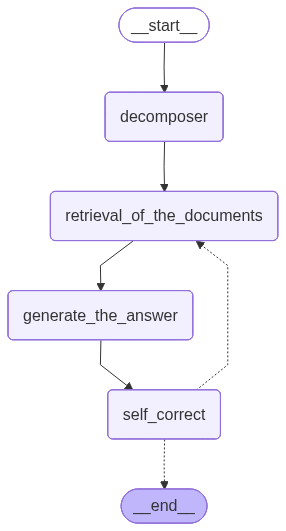

In [ ]:
workflow = StateGraph(AgentState)
workflow.add_node("planner", decompose_query)
workflow.add_node("retriever", retrieval_of_the_documents)
workflow.add_node("generator", generate_the_answer)
workflow.add_node("critic", self_correct)

workflow.add_edge(START, "planner")
workflow.add_edge("planner", "retriever")
workflow.add_edge("retriever","generator")
workflow.add_edge("generator","critic")

workflow.add_conditional_edges(
    "critic", should_continue,
    {
        "retriever":"retriever",
        END: END
    }
)

app = workflow.compile()

display(Image(app.get_graph().draw_mermaid_png()))



In [ ]:
result = app.invoke({
    "question": "student records for AI Code 491365 with High confidence index and test date and Sent to Scoring Date",
    "answer":"",
    "retrieved_documents": [],
    "retrieved_sources":[],
    "iteration": 0,
    "confidence_score":0.0
})

result['answer'] = NavigationResponse(
    question = result['question'],
    answer = result['answer']
).model_dump()

print (f"result is: {result['answer']}")
print (f"iteration is: {result['iteration']}")


Confidence 0.7 below threshold. Retrying (Iter 1)...
Confidence 0.7 below threshold. Retrying (Iter 2)...
Max retries (3) reached. Final confidence: 0.3
result is: {'question': 'student records for AI Code 491365 from texas state', 'answer': 'Please navigate to the Student Submission Report and use the pre-filters to search for AI Code 491365, as the system can pull millions of student exam records but requires filtering to avoid timeouts source(SAT School Day & PSAT Exam Schedule_final.pdf)'}
iteration is: 3
